# Customer Segmentation using K-Means Clustering

## Project Objective

The goal of this project is to segment customers based on their
spending behavior, satisfaction level and loyalty status using
K-Means clustering.

Customer segmentation helps businesses better understand their
customer base and design targeted marketing strategies.

## Load Dataset and Import Libraries

In [10]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("coffee_customers.csv")
df.head()

display(df.head())

,Age,Gender,VisitFrequency,WeeklySpend,DrinkPreference,LoyaltyMember,SatisfactionScore,Location
0,NaN,Male,Weekly,143.89,Americano,1,2.5,Campus
1,46.0,Female,Daily,NaN,Espresso,1,3.3,Downtown
2,32.0,Male,Weekly,11.18,Cappuccino,1,3.4,Suburb
3,38.0,Male,Weekly,12.62,Cappuccino,1,4.0,Suburb
4,NaN,Male,Weekly,5.52,NaN,0,4.5,Downtown


## Data Preprocessing
Before applying the clustering algorithm, the dataset needs to be cleaned and prepared.

The preprocessing steps include:

* Handling missing values
* Selecting relevant numerical features for clustering
* Scaling the features to ensure they contribute equally to the clustering process

In [11]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                4 non-null      float64
 1   Gender             10 non-null     object 
 2   VisitFrequency     10 non-null     object 
 3   WeeklySpend        9 non-null      float64
 4   DrinkPreference    9 non-null      object 
 5   LoyaltyMember      10 non-null     int64  
 6   SatisfactionScore  10 non-null     float64
 7   Location           10 non-null     object 
dtypes: float64(3), int64(1), object(4)
memory usage: 772.0+ bytes


,0
Age,6
Gender,0
VisitFrequency,0
WeeklySpend,1
DrinkPreference,1
LoyaltyMember,0
SatisfactionScore,0
Location,0


In [15]:
# Fill missing values
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['WeeklySpend'] = df['WeeklySpend'].fillna(df['WeeklySpend'].mean())
df['DrinkPreference'] = df['DrinkPreference'].fillna(df['DrinkPreference'].mode()[0])

df.isnull().sum()

,0
Age,0
Gender,0
VisitFrequency,0
WeeklySpend,0
DrinkPreference,0
LoyaltyMember,0
SatisfactionScore,0
Location,0


Missing values were treated differently depending on the variable type.

• Numerical variables (Age, WeeklySpend) were imputed using the mean value.  
• The categorical variable (DrinkPreference) was imputed using the mode, which represents the most frequent category.

This approach preserves the structure of the dataset while minimizing bias introduced by missing values.

## Feature Selection

For clustering, only numerical variables are used.
The following features were selected:

- Age
- Weekly Spending
- Loyalty Membership
- Satisfaction Score

In [17]:
numerical_features = ['Age', 'WeeklySpend', 'LoyaltyMember', 'SatisfactionScore']
display(numerical_features)

df_numerical = df[numerical_features]
df_numerical.head()


['Age', 'WeeklySpend', 'LoyaltyMember', 'SatisfactionScore']

,Age,WeeklySpend,LoyaltyMember,SatisfactionScore
0,36.0,143.890000,1,2.5
1,46.0,24.724444,1,3.3
2,32.0,11.180000,1,3.4
3,38.0,12.620000,1,4.0
4,36.0,5.520000,0,4.5


## Feature Scaling

The selected numerical features were standardized using **StandardScaler**.

Feature scaling is necessary for clustering algorithms such as K-Means because
variables with larger numerical ranges could otherwise dominate the clustering process.

StandardScaler transforms the data so that each feature has:

- mean = 0
- standard deviation = 1

In [19]:
from sklearn.preprocessing import StandardScaler

# Select numerical features
df_numerical = df[numerical_features]

# Initialize scaler
scaler = StandardScaler()

# Scale features
scaled_features = scaler.fit_transform(df_numerical)

scaled_features[:5]

scaled_df = pd.DataFrame(
    scaled_features,
    columns=numerical_features
)

scaled_df.head()

,Age,WeeklySpend,LoyaltyMember,SatisfactionScore
0,0.000000,2.974733,0.654654,-1.955508
1,2.331262,0.000000,0.654654,-0.952683
2,-0.932505,-0.338110,0.654654,-0.827330
3,0.466252,-0.302164,0.654654,-0.075212
4,0.000000,-0.479401,-1.527525,0.551553


## Determine the optimal number of clusters

Before applying K-Means clustering, it is important to determine the optimal number of clusters.

Two methods are used:

• **Elbow Method** – evaluates how the within-cluster sum of squares (inertia) changes as the number of clusters increases.  
• **Silhouette Score** – measures how well data points fit within their assigned clusters.

These methods help identify the number of clusters that best represents the structure of the data.


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


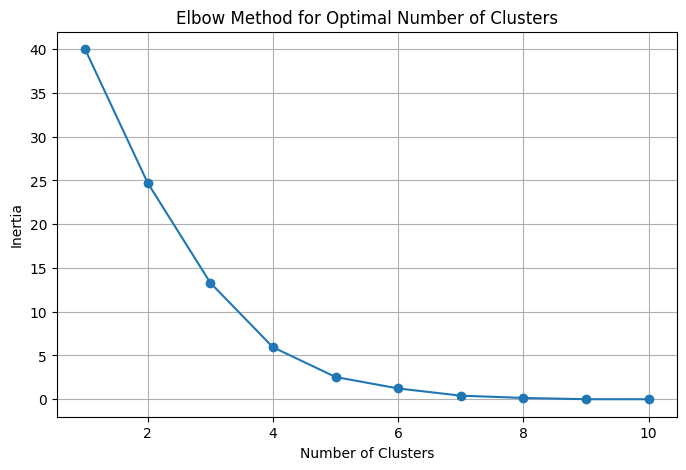

In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Range of clusters to test
cluster_range = range(1, 11)

inertia = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8,5))
plt.plot(cluster_range, inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.grid(True)
plt.show()

In [21]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, labels)
    silhouette_scores.append(score)

print("Silhouette Scores:")
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"k = {k}: {score:.3f}")

Silhouette Scores:
k = 2: 0.365
k = 3: 0.416
k = 4: 0.435
k = 5: 0.427
k = 6: 0.410
k = 7: 0.353
k = 8: 0.309
k = 9: 0.200
k = 10: 0.200


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (9) found smaller than n_clusters (10). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


### Interpretation

The elbow curve shows a clear bend around **k = 4**, suggesting that adding more clusters beyond this point results in only marginal improvement.

The silhouette scores also indicate that four clusters provide a good balance between cluster separation and cohesion.

Therefore, the number of clusters for the K-Means model is set to **4**.

## Apply K-Means Clustering

After determining the optimal number of clusters, the K-Means algorithm is applied to segment the customers.

The model groups customers into clusters based on similarities in:

- Age
- Weekly spending
- Loyalty membership
- Satisfaction score

Each customer is assigned to one cluster, which represents a specific behavioral segment.

In [22]:
from sklearn.cluster import KMeans

# Set number of clusters
n_clusters = 4

# Train K-Means model
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)

# Fit model and assign clusters
df['Cluster'] = kmeans.fit_predict(scaled_features)

df.head()

,Age,Gender,VisitFrequency,WeeklySpend,DrinkPreference,LoyaltyMember,SatisfactionScore,Location,Cluster
0,36.0,Male,Weekly,143.890000,Americano,1,2.5,Campus,0
1,46.0,Female,Daily,24.724444,Espresso,1,3.3,Downtown,3
2,32.0,Male,Weekly,11.180000,Cappuccino,1,3.4,Suburb,1
3,38.0,Male,Weekly,12.620000,Cappuccino,1,4.0,Suburb,1
4,36.0,Male,Weekly,5.520000,Americano,0,4.5,Downtown,2


In [23]:
cluster_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=numerical_features
)

cluster_centers

,Age,WeeklySpend,LoyaltyMember,SatisfactionScore
0,0.000000,2.974733,0.654654,-1.955508e+00
1,-0.466252,-0.322983,0.654654,-8.035239e-16
2,0.000000,-0.453273,-1.527525,9.693969e-01
3,2.331262,0.000000,0.654654,-9.526832e-01


In [24]:
df['Cluster'].value_counts()

,count
Cluster,
1,5
2,3
3,1
0,1


## Analyze Cluster Characteristics

To better understand the customer segments, the average values of the numerical features are calculated for each cluster.

This helps identify how the clusters differ in terms of:

- Age
- Weekly spending
- Loyalty membership
- Satisfaction score


In [25]:
cluster_characteristics = df.groupby('Cluster')[numerical_features].mean()

cluster_characteristics

,Age,WeeklySpend,LoyaltyMember,SatisfactionScore
Cluster,,,,
0,36.0,143.890000,1.0,2.500000
1,34.0,11.786000,1.0,4.060000
2,36.0,6.566667,0.0,4.833333
3,46.0,24.724444,1.0,3.300000


## Compare clusters with loyalty status

Analyze how the generated clusters correspond to the existing loyalty status.


In [27]:
loyalty_cluster_distribution = df.groupby(['Cluster', 'LoyaltyMember']).size().unstack(fill_value=0)
display(loyalty_cluster_distribution)


LoyaltyMember,0,1
Cluster,,
0,0,1
1,0,5
2,3,0
3,0,1


In [28]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,1
1,5
2,3
3,1


### Interpretation

The cluster analysis reveals several distinct customer segments.

Some clusters represent customers with higher weekly spending,
while others include customers with lower engagement or satisfaction levels.

These patterns can help businesses better understand customer behavior
and develop targeted marketing strategies or loyalty programs.

## Visualize results

The scatter plot visualizes customer segments based on weekly spending and satisfaction levels.

• Colors represent different clusters identified by the K-Means algorithm.  
• Marker styles indicate whether a customer is a loyalty program member.

This visualization helps illustrate how the clustering algorithm separates customers into distinct behavioral groups.

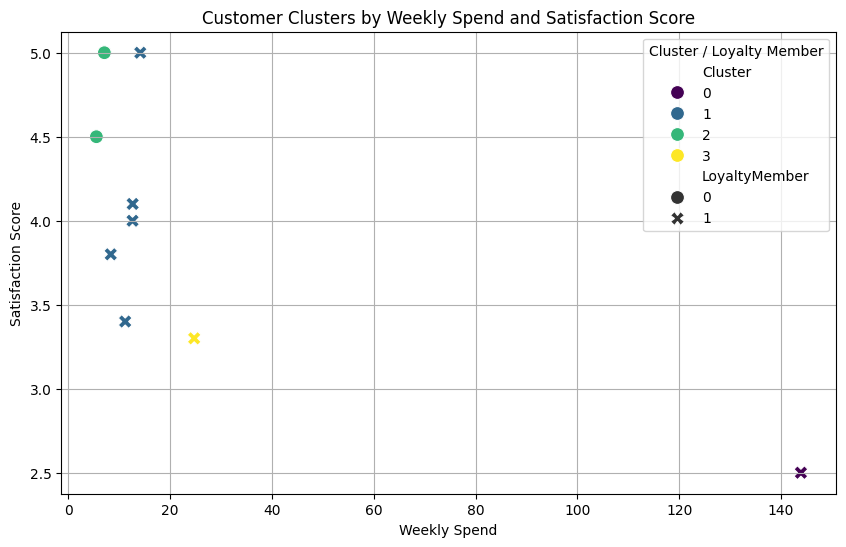

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='WeeklySpend',
    y='SatisfactionScore',
    hue='Cluster',
    style='LoyaltyMember',
    palette='viridis',
    s=100
)

plt.title('Customer Clusters by Weekly Spend and Satisfaction Score')
plt.xlabel('Weekly Spend')
plt.ylabel('Satisfaction Score')
plt.legend(title='Cluster / Loyalty Member', loc='upper right')
plt.grid(True)

plt.show()

## Summary

### Key Findings

This project applied K-Means clustering to segment customers based on behavioral and demographic characteristics.

Key findings include:

- The numerical features used for clustering were **Age, WeeklySpend, LoyaltyMember, and SatisfactionScore**.
- Missing values in **Age** and **WeeklySpend** were handled using mean imputation, while categorical variables were filled using the mode.
- The **Elbow Method** and **Silhouette Score** indicated that **4 clusters** provide an appropriate segmentation of the dataset.
- A K-Means model with four clusters was trained and cluster labels were assigned to each customer.
- Cluster analysis revealed distinct differences in **spending behavior, satisfaction levels, and loyalty membership** across the customer groups.
- The visualization of **WeeklySpend vs. SatisfactionScore** showed clear behavioral patterns between the clusters.

### Insights

The clustering results suggest that customers can be grouped into distinct behavioral segments based on spending and satisfaction levels.

Some clusters represent **high-engagement customers**, while others include customers with lower spending or loyalty engagement. Understanding these segments can help businesses design **targeted marketing strategies and customer retention programs**.

### Possible Next Steps

Future improvements could include:

- Testing additional clustering algorithms such as **Hierarchical Clustering or DBSCAN**
- Incorporating additional behavioral features (e.g., visit frequency or location)
- Applying the model to a **larger dataset** for more robust segmentation
- Developing **customer profiles** for each cluster to support personalized marketing strategies